In [167]:
import kagglehub

path = kagglehub.dataset_download("oscarbatiz/los-angeles-airbnb-listings")
print("Path to dataset files:", path)



Using Colab cache for faster access to the 'los-angeles-airbnb-listings' dataset.
Path to dataset files: /kaggle/input/los-angeles-airbnb-listings


In [168]:
import pandas as pd
import os

file_path = os.path.join(path, "listings.csv")
df_raw = pd.read_csv(file_path, encoding="latin1", low_memory=False)
df = df_raw.copy()

#for col in df.select_dtypes(include="object").columns:
#    df[col] = df[col].map(
#        lambda x: ftfy.fix_text(x) if isinstance(x, str) else x
#    )

In [169]:

df.head()
df.tail()
df.sample(8)

,id,name,host_id,host_name,host_since,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,...,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating,license,instant_bookable
36403,42573226,C. Super clean bright elegant roomå¹²åæ´æ´...,307485348,Rachel,43775,NaN,NaN,f,Diamond Bar,Other Cities,...,NaN,NaN,NaN,NaN,30,0,3,5.00,NaN,f
17724,1159962841772472915,Nice room in Charming Condo,345180118,Oswaldo,43953,within an hour,1.0,f,Pasadena,Other Cities,...,1.0,0.0,2.0,95.0,1,254,3,3.67,NaN,f
8109,1139484216934066051,NoHo Luxury Home w/ Rooftop Deck,65000336,William,30/03/16,within an hour,1.0,t,North Hollywood,City of Los Angeles,...,4.0,3.0,3.0,318.0,30,180,0,NaN,NaN,f
25684,39607590,Hollywood Cool and Luxurious 18,31830429,Joseph,42118,within an hour,0.9,f,Hollywood Hills,City of Los Angeles,...,1.0,1.0,1.0,126.0,31,365,7,4.86,NaN,f
8971,7308021,1 Bedroom Venice Beachpad w Parking-M14,25326961,Mike,28/12/14,within an hour,1.0,t,Venice,City of Los Angeles,...,1.0,1.0,2.0,89.0,31,258,29,4.93,NaN,f
28192,45608028,"Gated Loft, Close to Trails & Minutes to the B...",68069,Christina,40183,within an hour,1.0,t,Calabasas,Other Cities,...,1.0,1.0,1.0,188.0,5,365,77,5.00,NaN,f
40186,30571691,Looking to rent spare rooms short term/ long term,7249871,Natasha,41457,NaN,NaN,f,Hermosa Beach,Other Cities,...,NaN,2.0,NaN,NaN,30,0,0,NaN,NaN,f
9557,8722094,Complete guest - Modern Place near LAX,42859065,Alba,29/08/15,within an hour,1.0,t,Playa Vista,City of Los Angeles,...,1.0,1.0,1.0,130.0,30,365,75,4.95,HSR20-002303,f


In [170]:
print('\n\n-------------------------------')
print(df.info())
describe_df = df.describe()

print('\n\n-------------------------------')
print(df.dtypes)



-------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45533 entries, 0 to 45532
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            45533 non-null  int64  
 1   name                          45532 non-null  object 
 2   host_id                       45533 non-null  int64  
 3   host_name                     45531 non-null  object 
 4   host_since                    45531 non-null  object 
 5   host_response_time            35445 non-null  object 
 6   host_response_rate            35445 non-null  float64
 7   host_is_superhost             44281 non-null  object 
 8   neighbourhood_cleansed        45533 non-null  object 
 9   neighbourhood_group_cleansed  45533 non-null  object 
 10  latitude                      45533 non-null  float64
 11  longitude                     45533 non-null  float64
 12  property_type             

In [171]:
print(df.shape)
print("-----------")
df.info()
print("-----------")
df.columns

(45533, 25)
-----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45533 entries, 0 to 45532
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            45533 non-null  int64  
 1   name                          45532 non-null  object 
 2   host_id                       45533 non-null  int64  
 3   host_name                     45531 non-null  object 
 4   host_since                    45531 non-null  object 
 5   host_response_time            35445 non-null  object 
 6   host_response_rate            35445 non-null  float64
 7   host_is_superhost             44281 non-null  object 
 8   neighbourhood_cleansed        45533 non-null  object 
 9   neighbourhood_group_cleansed  45533 non-null  object 
 10  latitude                      45533 non-null  float64
 11  longitude                     45533 non-null  float64
 12  property_type                 45533 

Index(['id', 'name', 'host_id', 'host_name', 'host_since',
       'host_response_time', 'host_response_rate', 'host_is_superhost',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'price', 'minimum_nights', 'availability_365',
       'number_of_reviews', 'review_scores_rating', 'license',
       'instant_bookable'],
      dtype='object')

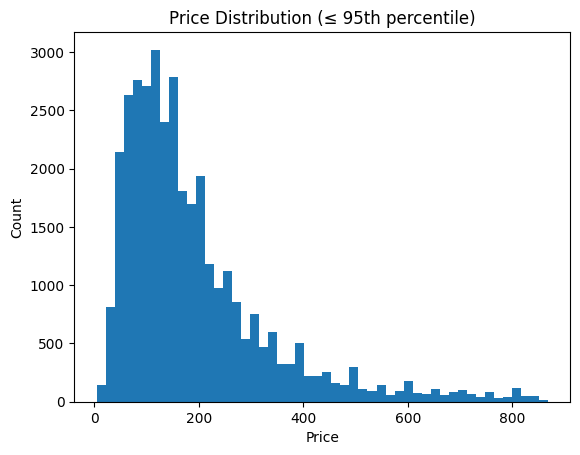

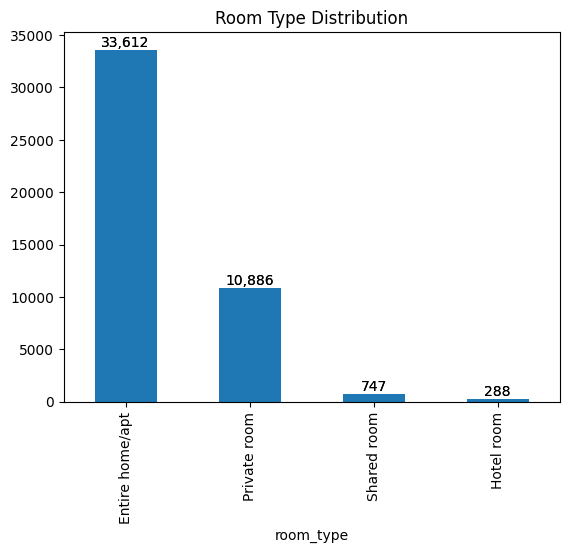

In [172]:
import matplotlib.pyplot as plt

#price vs reservations
price = df["price"].dropna()
upper = price.quantile(0.95)

plt.hist(price[price <= upper], bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution (≤ 95th percentile)")
plt.show()

#types of rooms
ax = df["room_type"].value_counts().plot(kind="bar")
df["room_type"].value_counts().plot(kind="bar")
plt.title("Room Type Distribution")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.show()


In [173]:
df = df_raw.copy() # Re-initialize df from df_raw to ensure all columns are present

ratings_mean = df["review_scores_rating"].mean()
df["review_scores_rating"] = df["review_scores_rating"].fillna(ratings_mean)

price_mean = df["price"].mean()
df["price"] = df["price"].fillna(price_mean)

bedrooms_mean = df["bedrooms"].mean()
df["bedrooms"] = df["bedrooms"].fillna(bedrooms_mean)

# Drop specified columns and update df
df = df.drop(columns=['license', 'host_response_time', 'host_response_rate', 'bathrooms', 'beds', 'host_is_superhost', 'host_name', 'host_since', 'host_id', 'id', 'availability_365', 'instant_bookable', 'number_of_reviews', 'neighbourhood_group_cleansed', 'minimum_nights', 'property_type'])
df['city'] = 'Los Angeles'

df.isna().sum().sort_values(ascending=False)

,0
name,1
neighbourhood_cleansed,0
latitude,0
longitude,0
room_type,0
accommodates,0
bedrooms,0
price,0
review_scores_rating,0
city,0


In [174]:
df.to_csv('la_cleaned.csv', index=False)
print('DataFrame successfully exported to la_cleaned.csv')

DataFrame successfully exported to la_cleaned.csv


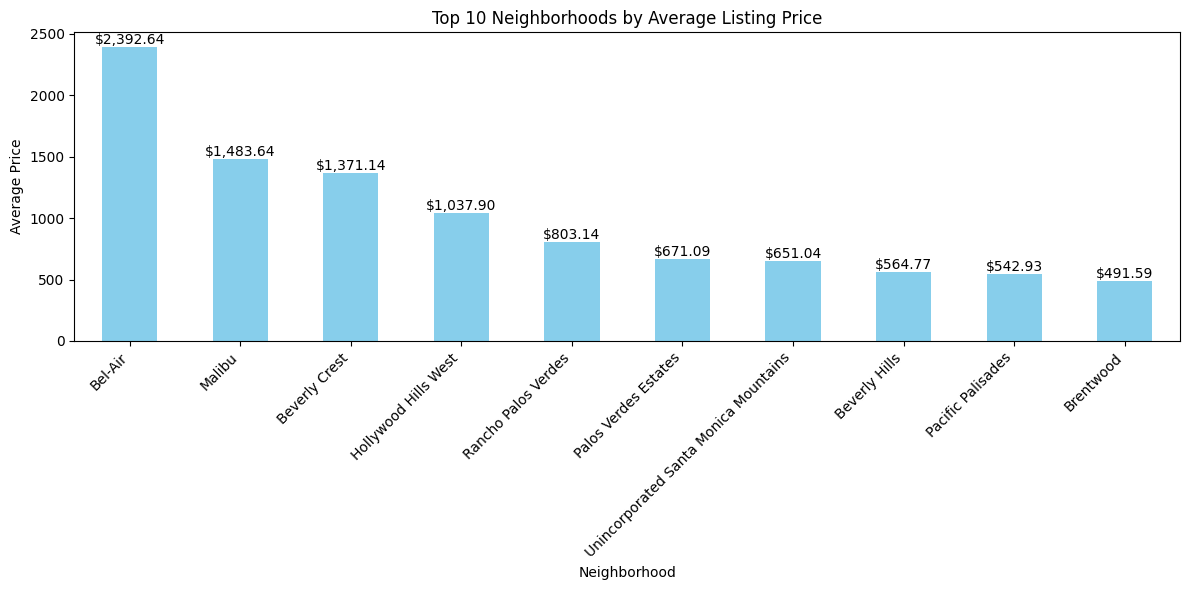

In [175]:
import matplotlib.pyplot as plt

# Calculate the average price for each neighborhood and sort them
top_10_neighborhoods_by_price = df.groupby("neighbourhood_cleansed")["price"].mean().nlargest(10)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))
top_10_neighborhoods_by_price.plot(kind="bar", ax=ax, color='skyblue')

plt.title("Top 10 Neighborhoods by Average Listing Price")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha="right")

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(
        f"${p.get_height():,.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

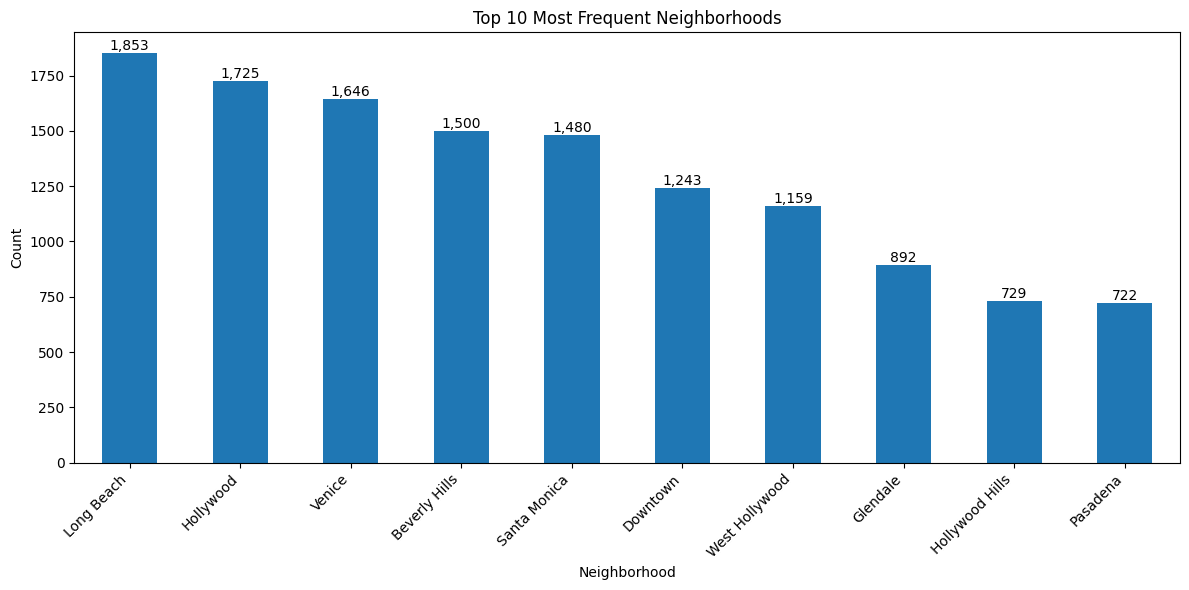

In [176]:
import matplotlib.pyplot as plt

top_10_neighborhoods = df["neighbourhood_cleansed"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
top_10_neighborhoods.plot(kind="bar", ax=ax)
plt.title("Top 10 Most Frequent Neighborhoods")
plt.xlabel("Neighborhood")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.tight_layout()
plt.show()

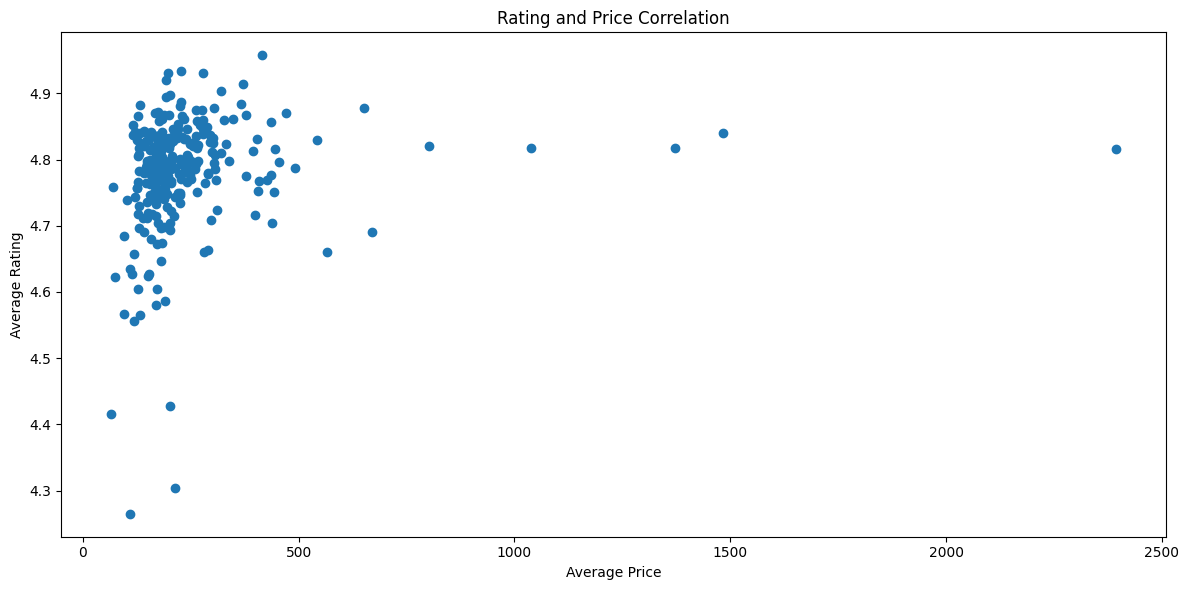

In [177]:
import matplotlib.pyplot as plt

# Calculate average price and average rating per neighborhood
neighborhood_stats = df.groupby("neighbourhood_cleansed").agg(
    avg_price=("price", "mean"),
    avg_rating=("review_scores_rating", "mean")
).reset_index()

# Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(x=neighborhood_stats["avg_price"], y=neighborhood_stats["avg_rating"])

plt.title("Rating and Price Correlation")
plt.xlabel("Average Price")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

In [178]:
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols].describe()

,latitude,longitude,accommodates,bedrooms,price,review_scores_rating
count,45533.000000,45533.000000,45533.000000,45533.000000,45533.000000,45533.000000
mean,34.055308,-118.312743,4.019876,1.786817,289.377762,4.778747
std,0.141394,0.172210,2.861610,1.293689,647.434496,0.355404
min,33.338360,-118.917134,1.000000,0.000000,5.000000,0.000000
25%,33.998590,-118.413090,2.000000,1.000000,110.000000,4.778747
50%,34.060625,-118.343391,3.000000,1.000000,192.000000,4.800000
75%,34.108160,-118.233737,6.000000,2.000000,289.377762,4.980000
max,34.811183,-117.653352,16.000000,50.000000,56425.000000,5.000000


In [179]:
df["room_type"].value_counts()

,count
room_type,
Entire home/apt,33612
Private room,10886
Shared room,747
Hotel room,288


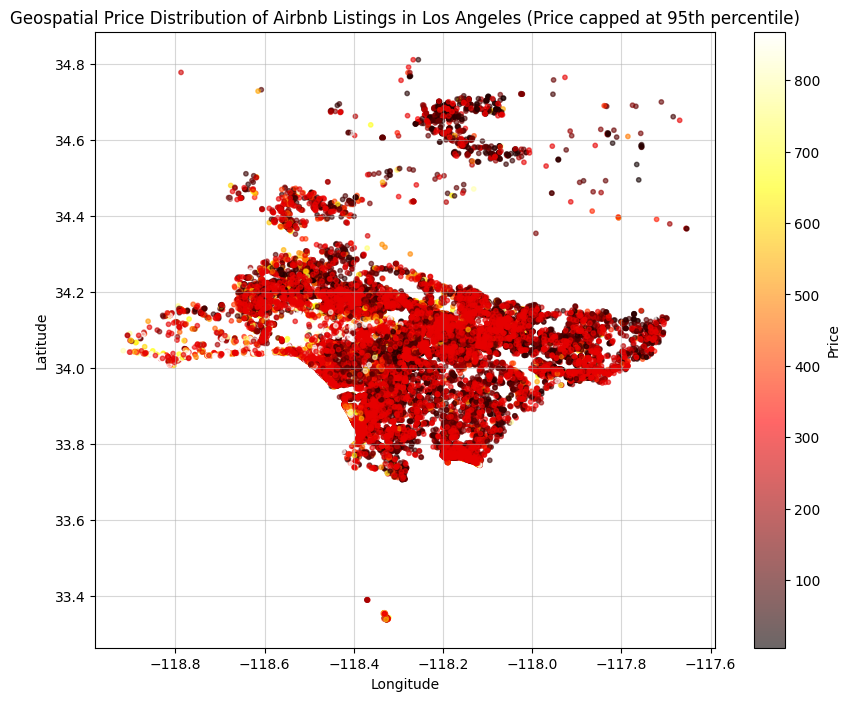

In [180]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(x=df['longitude'], y=df['latitude'], c=df['price'].clip(upper=upper), cmap='hot', alpha=0.6, s=10)
plt.colorbar(label='Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geospatial Price Distribution of Airbnb Listings in Los Angeles (Price capped at 95th percentile)')
plt.grid(True, alpha=0.5)
plt.show()

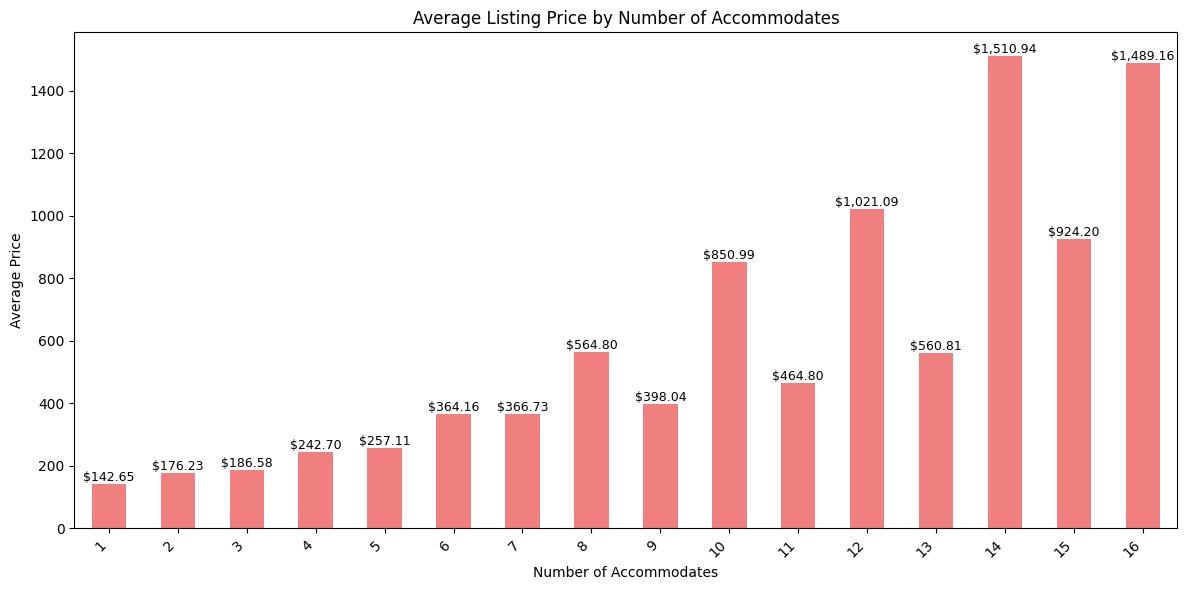

In [181]:
import matplotlib.pyplot as plt

# Calculate the average listing price for each 'accommodates' value
avg_price_by_accommodates = df.groupby('accommodates')['price'].mean()

# Create the bar chart
plt.figure(figsize=(12, 6))
avg_price_by_accommodates.plot(kind='bar', color='lightcoral')

# Add labels and title
plt.xlabel('Number of Accommodates')
plt.ylabel('Average Price')
plt.title('Average Listing Price by Number of Accommodates')

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=45, ha='right')

# Add value labels on top of the bars
for index, value in enumerate(avg_price_by_accommodates):
    plt.text(index, value, f'${value:,.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [184]:
la = pd.read_csv("la_cleaned.csv")
la.sample(6)

,name,neighbourhood_cleansed,latitude,longitude,room_type,accommodates,bedrooms,price,review_scores_rating,city
32708,Art Deco Stylized Gorgeous 2Bd+2Br,Encino,34.166550,-118.517240,Entire home/apt,4,2.0,150.0,4.840000,Los Angeles
13657,"Private,luxury, Guest House-Westside BESTLocat...",Rancho Park,34.039560,-118.428750,Entire home/apt,2,0.0,120.0,5.000000,Los Angeles
41401,Deluxe Hotel Style Unit,Pico-Robertson,34.058251,-118.383021,Entire home/apt,2,1.0,120.0,4.778747,Los Angeles
30515,Lovely private room in the heart of DTLA.,Downtown,34.038769,-118.247134,Private room,1,1.0,35.0,4.778747,Los Angeles
23246,Cute 1 Bedroom Home,Glendale,34.170420,-118.294230,Entire home/apt,4,1.0,193.0,4.800000,Los Angeles
27445,Modern LArge 2bd-2bth Apartment in Downtown LA...,Westlake,34.052694,-118.263086,Entire home/apt,4,2.0,170.0,4.800000,Los Angeles
